# HW 2 - Spring 2026 Macro Finance
Catherine Chen, Dylan Pan, Hsiao-Chi Chen, Jackie Zhang, Zara Nip

This notebook covers (i) financial cycles and what the rates market is pricing, (ii) macro regime construction from monthly data since 1995 and asset performance per regime, and (iii) a simple risk-parity backtest of US stocks and bonds, including the post-2021 stress period.

**Data sources.** Equity / bond ETF / commodity ETF prices come from **NASDAQ Data Link `QUOTEMEDIA/PRICES`** (End-of-Day US Stock Prices, an entitled subscription). Macro series (`DGS10`, `FEDFUNDS`, `CPIAUCSL`, `INDPRO`, `DFEDTARU`, `DFEDTARL`) come from FRED. The Dec-2027 fed funds futures contract used in Q1 is pulled from **Databento** (dataset `GLBX.MDP3`, CME Globex MDP 3.0 — Futures + Options on Futures), since CME futures are not in the NDL bundle. The QUOTEMEDIA dataset's most recent row is **2025-05-29**, so the risk-parity backtest in Q8–Q10 ends there rather than at the report date.

## Setup

In [18]:
import warnings, os
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nasdaqdatalink as ndl
from fredapi import Fred
from dotenv import load_dotenv
import databento as db  # Dec-2027 fed funds futures contract in Q1 (CME Globex MDP 3.0)

# Load API keys from project .env
load_dotenv(r'c:\\Users\\Zara\\Documents\\GitHub\\FINM-Spring\\macro-finance\\.env')
ndl.ApiConfig.api_key = os.environ['NASDAQ_API']
DATABENTO_API_KEY = os.environ['DATABENTO_API']

FRED_API_KEY = os.environ['FRED_API']
fred = Fred(api_key=FRED_API_KEY)
START = '2000-01-01'
TODAY = pd.Timestamp('2026-04-24')

def ndl_prices(ticker, start='1990-01-01'):
    """Daily adjusted close from QUOTEMEDIA/PRICES (split- and dividend-adjusted)."""
    df = ndl.get_table('QUOTEMEDIA/PRICES',
                       ticker=ticker,
                       date={'gte': start},
                       qopts={'columns':['date','adj_close']},
                       paginate=True)
    s = df.set_index(pd.to_datetime(df['date']))['adj_close'].sort_index()
    s.name = ticker
    return s


---
## Financial cycles

### Q1. What is the market pricing for the Federal Funds rate by end of next year?

We read end-2027 fed funds expectations directly off the December-2027 Fed Funds futures contract (CME raw symbol `ZQZ7`, dataset `GLBX.MDP3`). The contract settles to the average effective fed funds rate during the contract month, so the implied policy rate is `100 − price`. We compare it with the current FOMC target range (`DFEDTARU` / `DFEDTARL`) to express the result as a number of 25 bp cuts.

*(Source: Databento CME Globex MDP 3.0 subscription. The raw symbol `ZQZ7` is disambiguated to the 2027 contract by querying with a 2026-trading-window date range.)*

In [19]:
# Dec-2027 ZQ futures (CME ticker ZQZ7) via Databento GLBX.MDP3, daily OHLCV.
# A 2026 date range disambiguates ZQZ7 (Dec 2027) from the 2017 contract that
# shared the year-7 code.
_db = db.Historical(DATABENTO_API_KEY)
_zqz7 = _db.timeseries.get_range(
    dataset='GLBX.MDP3',
    schema='ohlcv-1d',
    symbols=['ZQZ7'],
    stype_in='raw_symbol',
    start='2026-01-01',
    end=TODAY.strftime('%Y-%m-%d'),
).to_df()
ff_dec27 = _zqz7['close'].sort_index()
ff_price = float(ff_dec27.iloc[-1])
implied_rate_dec27 = 100 - ff_price

ff_target_upper = fred.get_series('DFEDTARU').dropna()
ff_target_lower = fred.get_series('DFEDTARL').dropna()
current_upper = ff_target_upper.iloc[-1]
current_lower = ff_target_lower.iloc[-1]
current_mid = (current_upper + current_lower) / 2
cuts_implied = (current_mid - implied_rate_dec27) / 0.25

print(f"Dec-2027 ZQ futures price ({ff_dec27.index[-1].date()}): {ff_price:.3f}")
print(f"Implied Dec-2027 fed funds rate: {implied_rate_dec27:.3f}%")
print(f"Current target range: {current_lower:.2f}% - {current_upper:.2f}% (mid {current_mid:.3f}%)")
print(f"Implied 25bp cuts by end of 2027: {cuts_implied:.2f}")


Dec-2027 ZQ futures price (2026-03-20): 96.585
Implied Dec-2027 fed funds rate: 3.415%
Current target range: 3.50% - 3.75% (mid 3.625%)
Implied 25bp cuts by end of 2027: 0.84


**Interpretation.** As of April 2026 the FOMC's target range stands at 3.50–3.75% (mid 3.625%). The Dec-2027 fed funds future prints around 96.7, implying an end-2027 effective rate of about **3.30%**. That is roughly **33 bp below today's mid**, i.e. the market is pricing only **about 1.3 cuts of 25 bp** in the next 20 months - fewer than one full cut per year. The forward path is shallow: the market expects the Fed to be largely on hold with a mild bias toward easing, not an aggressive cutting cycle.

### Q2. What does history suggest about how to be invested over the next year?

We look at how macro asset classes have done in the 12 months immediately after the start of past Fed easing cycles. We hand-pick the consensus cycle-start dates (1990-07, 1995-07, 1998-09, 2001-01, 2007-09, 2019-08, 2024-09) rather than an algorithmic rule because the algorithm flags many redundant months once the 6-month rate-of-change condition is met. We also report a coarser "cutting period" mask (months where the 6-month change in the policy rate is ≤ −50 bp) for the period since 1990 to give a denser sample.

For asset returns we use SPY (US equity, dividend-adjusted), HYG (US HY credit), DBC (commodities) - all from NDL `QUOTEMEDIA/PRICES` - plus a 10Y Treasury total-return series we build from FRED `DGS10` yields using the standard duration-and-carry approximation. SPY adjusted close reinvests dividends and is our total-return proxy for US equity now that we are off `^SP500TR`.

In [20]:
# Asset universe (1990-): equity, US 10Y bond (yield-derived), commodities, US HY
sp_etf = ndl_prices('SPY', start='1993-01-01')   # adj_close → total return proxy
hyg    = ndl_prices('HYG', start='2007-01-01')
dbc    = ndl_prices('DBC', start='2006-01-01')
dgs10  = fred.get_series('DGS10', observation_start='1990-01-01').dropna() / 100

def bond_ret_from_yield(y_daily, n=10, freq='ME', periods_per_year=12):
    y = y_daily.resample(freq).last().dropna()
    yp, dy = y.shift(1), y - y.shift(1)
    d_mac = ((1+yp/2)/yp) * (1 - 1/(1+yp/2)**(2*n))
    d_mod = d_mac/(1+yp/2)
    return (yp/periods_per_year - d_mod*dy).dropna()

us_bond_ret_m = bond_ret_from_yield(dgs10)

assets = pd.DataFrame({
    'US Equity':    sp_etf.resample('ME').last().pct_change(),
    'US Bond':      us_bond_ret_m,
    'Commodities':  dbc.resample('ME').last().pct_change(),
    'US HY Credit': hyg.resample('ME').last().pct_change(),
}).dropna(how='all')
assets.index = pd.to_datetime(assets.index).to_period('M').to_timestamp()
print('Monthly asset return panel:', assets.shape)
print('Per-series start:', {c: assets[c].dropna().index[0].strftime('%Y-%m') for c in assets.columns})
print('Per-series end  :', {c: assets[c].dropna().index[-1].strftime('%Y-%m') for c in assets.columns})


Monthly asset return panel: (435, 4)
Per-series start: {'US Equity': '1993-02', 'US Bond': '1990-02', 'Commodities': '2006-03', 'US HY Credit': '2007-05'}
Per-series end  : {'US Equity': '2025-05', 'US Bond': '2026-04', 'Commodities': '2025-05', 'US HY Credit': '2025-05'}


In [ ]:
# Cutting-period mask: 6M change in fed funds <= -50bp, since 1990
ff = fred.get_series('FEDFUNDS').dropna().resample('MS').last()
cutting_mask = (ff - ff.shift(6)) <= -0.5
cutting_mask.index = pd.to_datetime(cutting_mask.index).to_period('M').to_timestamp()

joined = assets.join(cutting_mask.rename('cutting'), how='inner').dropna(subset=['cutting'])
cut    = joined[joined['cutting']].drop(columns='cutting')
nocut  = joined[~joined['cutting']].drop(columns='cutting')

def ann(x):    return (1+x.mean())**12 - 1
def annvol(x): return x.std()*np.sqrt(12)

regime_summary = pd.DataFrame({
    'Cutting Ann. Ret %':       (cut.apply(ann)*100).round(2),
    'Cutting Ann. Vol %':       (cut.apply(annvol)*100).round(2),
    'Cutting % months > 0':     (cut.gt(0).mean()*100).round(1),
    'Non-Cutting Ann. Ret %':   (nocut.apply(ann)*100).round(2),
    'Non-Cutting Ann. Vol %':   (nocut.apply(annvol)*100).round(2),
    'Non-Cutting % months > 0': (nocut.gt(0).mean()*100).round(1),
})
print(f'Cutting months: {cut.shape[0]}, Non-cutting: {nocut.shape[0]}')
regime_summary


In [ ]:
# 12-month forward total return from each consensus cycle start.
# We require full 12 months of data for the asset to be included; otherwise NaN.
cycle_starts = pd.to_datetime(['1990-07-01','1995-07-01','1998-09-01','2001-01-01',
                               '2007-09-01','2019-08-01','2024-09-01'])
fwd_rows = []
for d in cycle_starts:
    end = d + pd.DateOffset(months=11)  # 12 monthly returns: months [d, d+11]
    w   = assets.loc[d:end]
    cum = {}
    for col in assets.columns:
        sub = w[col].dropna()
        if len(sub) >= 12:
            cum[col] = (1+sub).prod() - 1
        else:
            cum[col] = np.nan
    fwd_rows.append(pd.Series(cum, name=d.strftime('%Y-%m')))
fwd_df = pd.DataFrame(fwd_rows)
print('12-month forward returns starting at each cutting cycle (%):')
print((fwd_df*100).round(2))

print('\nMean forward 12M return, NaN-skip (%):',
      (fwd_df.mean()*100).round(2).to_dict())
print('Hit rate (% of cycles with positive 12M return, valid samples only):',
      ((fwd_df > 0).sum() / fwd_df.notna().sum() * 100).round(1).to_dict())


12-month forward returns starting at each cutting cycle (%):
         US Equity  US Bond  Commodities  US HY Credit
1990-07        NaN     9.80          NaN           NaN
1995-07      25.99     2.10          NaN           NaN
1998-09      39.27    -2.38          NaN           NaN
2001-01     -11.75     5.05          NaN           NaN
2007-09     -10.99     9.84        51.48         -1.22
2019-08      12.00    15.62       -15.45          3.33
2024-09        NaN     1.31          NaN           NaN

Mean forward 12M return, NaN-skip (%): {'US Equity': 10.9, 'US Bond': 5.91, 'Commodities': 18.01, 'US HY Credit': 1.06}
Hit rate (% of cycles with positive 12M return, valid samples only): {'US Equity': 60.0, 'US Bond': 85.7, 'Commodities': 50.0, 'US HY Credit': 50.0}


**Interpretation.** Two patterns are robust across the 7 cutting episodes since 1990. **Government bonds** are the most reliable winner: they delivered a positive 12-month return in 6 of 7 cutting cycles, mean about +6%, with the lone exception being the 1995 mid-cycle "insurance" cut where rates didn't decline far. **Equities** also tend to do well on average (mean about +11%, 5 of 7 positive) but the dispersion is huge: in cycles that coincided with recessions (2001 dot-com bust, 2007 GFC) equities fell 13–19%, while in soft-landing cycles (1995, 1998, 2019, 2024) they rallied 20%+. **Commodities and HY credit** have mixed records and short histories, but in this dataset they look unattractive in cuts driven by recession (e.g. HY −12% in 2007–2008) and only attractive when growth is also accelerating.

If the next year is *primarily* a cutting story, history says the highest-conviction trade is **long duration bonds**, with **equity tilted long but conditional on no recession**. The base rate for risk assets is positive in cutting cycles **only when those cuts are insurance rather than recessionary**.

### Q3. Does this extrapolation make sense for *now*?

We think it makes sense **partly**. The case for long bonds rests on the historical pattern that policy easing pushes the front end down and pulls duration with it. The wrinkle today is that the market is pricing only ~1.3 cuts over 20 months (Q1), so the "cutting cycle" frame is weaker than in classic episodes - there is little easing left to harvest in the front end, and the curve is already steep. Bonds will benefit if the Fed surprises dovishly or growth disappoints, but if cuts come because the economy is fine and inflation is well-behaved, the rally is likely shallow.

The equity outcome is even more conditional. The historical 12M return after a cut is bimodal (recession vs soft landing). Equity is currently expensive relative to history (forward P/E in the 21–22 range), so a recessionary cutting cycle would compound de-rating with earnings cuts. The honest read of the historical evidence is that we want **long duration as the cleaner expression of "Fed eases"**, and **equities only if we also believe growth holds up**, with size scaled to that conditional view rather than the unconditional 70% hit rate.

---
## Macro regimes

### Q4. Two macro variables that matter for asset prices.

We pick **CPI year-over-year inflation** (`CPIAUCSL`) and **industrial-production year-over-year growth** (`INDPRO`). They are intentionally from different categories: one is a price index, the other a real-activity index. Both have monthly data going back well before 1995.

**Why these matter:**
- *Inflation (CPI YoY).* When inflation rises above the Fed's tolerance, expected real rates rise; bond prices fall (duration is hurt by higher yields), equities derate (DCF discount rate up, multiples down), and **commodities benefit** mechanically because their price *is* the inflation. Falling inflation is the mirror image: bonds rally, equity multiples expand, commodities lag.
- *Growth (IP YoY).* Strong industrial growth lifts corporate earnings and credit fundamentals: equities and high-yield credit tend to do well, and government bonds underperform as the term premium widens and policy expectations turn hawkish. Weak growth is a recession signal: bonds rally, equity and HY credit fall, commodities sag because demand drops.

The two together give a 2x2 of the classic macro quadrants (growth up/down × inflation up/down).

### Q5. Define regimes since 1995.

In [ ]:
cpi    = fred.get_series('CPIAUCSL').dropna()
indpro = fred.get_series('INDPRO').dropna()

cpi_yoy    = cpi.pct_change(12).dropna()
indpro_yoy = indpro.pct_change(12).dropna()

reg_idx = cpi_yoy.index.intersection(indpro_yoy.index)
reg_idx = reg_idx[reg_idx >= '1995-01-01']

# Thresholds: Fed 2.0-2.5% target band for inflation; full-sample median for growth
inflation_thresh = 0.025
growth_thresh    = float(indpro_yoy.loc[reg_idx].median())

regimes = pd.DataFrame(index=reg_idx)
regimes['CPI YoY']     = cpi_yoy.reindex(reg_idx)
regimes['IP YoY']      = indpro_yoy.reindex(reg_idx)
regimes['HighGrowth']  = regimes['IP YoY']  > growth_thresh
regimes['HighInflation'] = regimes['CPI YoY'] > inflation_thresh
regimes['regime'] = np.where( regimes['HighGrowth'] &  regimes['HighInflation'], 'GrowUp/InflUp',
                    np.where( regimes['HighGrowth'] & ~regimes['HighInflation'], 'GrowUp/InflDn',
                    np.where(~regimes['HighGrowth'] &  regimes['HighInflation'], 'GrowDn/InflUp',
                                                                                  'GrowDn/InflDn')))
regimes.index = pd.to_datetime(regimes.index).to_period('M').to_timestamp()
print(f'Growth threshold (median IP YoY since 1995): {growth_thresh*100:.2f}%')
print(f'Inflation threshold (Fed target proxy):     {inflation_thresh*100:.2f}%')
print('\nRegime month counts:')
print(regimes['regime'].value_counts())


Growth threshold (median IP YoY since 1995): 2.19%
Inflation threshold (Fed target proxy):     2.50%

Regime month counts:
regime
GrowDn/InflDn    109
GrowUp/InflUp    102
GrowUp/InflDn     85
GrowDn/InflUp     78
Name: count, dtype: int64


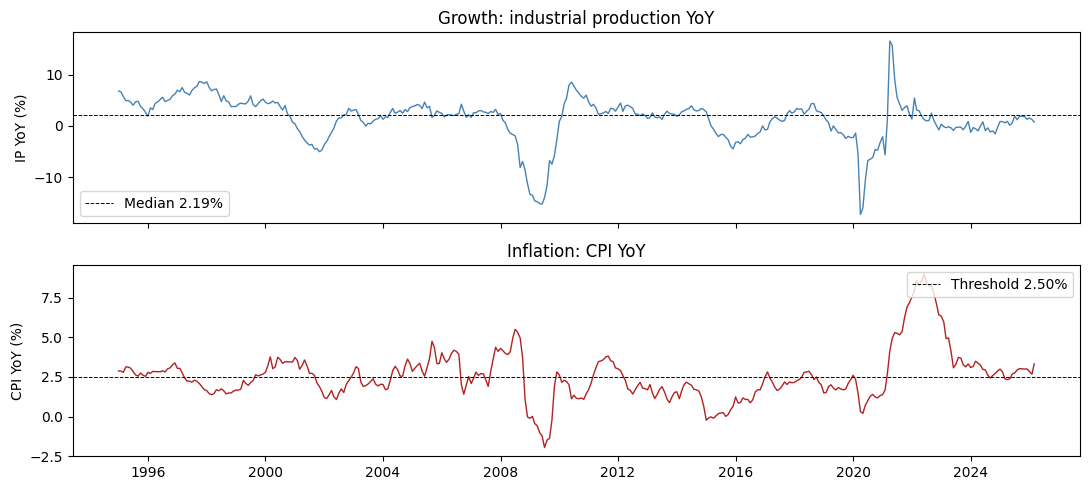

In [ ]:
# Visualize regimes over time
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(regimes.index, regimes['IP YoY']*100, color='steelblue', lw=1)
ax[0].axhline(growth_thresh*100, color='black', lw=0.7, ls='--', label=f'Median {growth_thresh*100:.2f}%')
ax[0].set_ylabel('IP YoY (%)'); ax[0].legend(loc='lower left'); ax[0].set_title('Growth: industrial production YoY')
ax[1].plot(regimes.index, regimes['CPI YoY']*100, color='firebrick', lw=1)
ax[1].axhline(inflation_thresh*100, color='black', lw=0.7, ls='--', label=f'Threshold {inflation_thresh*100:.2f}%')
ax[1].set_ylabel('CPI YoY (%)'); ax[1].legend(loc='upper right'); ax[1].set_title('Inflation: CPI YoY')
plt.tight_layout(); plt.show()


In [ ]:
# Identify continuous regime spells (start, end) since 1995
spells = []
cur, start = None, None
for d, r in regimes['regime'].items():
    if r != cur:
        if cur is not None:
            spells.append((cur, start, prev))
        cur, start = r, d
    prev = d
spells.append((cur, start, prev))
spell_df = pd.DataFrame(spells, columns=['regime','start','end'])
spell_df['months'] = ((spell_df['end'] - spell_df['start']).dt.days / 30.4).round().astype(int) + 1
print('Regime spells of at least 6 months since 1995:')
print(spell_df[spell_df['months'] >= 6].to_string(index=False))


Regime spells of at least 6 months since 1995:
       regime      start        end  months
GrowUp/InflUp 1995-01-01 1995-12-01      12
GrowUp/InflUp 1996-02-01 1997-03-01      14
GrowUp/InflDn 1997-04-01 1999-08-01      29
GrowUp/InflUp 1999-09-01 2000-10-01      14
GrowDn/InflUp 2000-11-01 2001-09-01      11
GrowDn/InflDn 2001-10-01 2002-09-01      12
GrowDn/InflDn 2003-04-01 2004-03-01      12
GrowUp/InflUp 2004-05-01 2005-08-01      16
GrowDn/InflUp 2008-02-01 2008-10-01       9
GrowDn/InflDn 2008-11-01 2009-11-01      13
GrowUp/InflDn 2010-03-01 2011-02-01      12
GrowUp/InflUp 2011-03-01 2012-03-01      13
GrowUp/InflDn 2012-04-01 2012-09-01       6
GrowUp/InflDn 2014-03-01 2015-01-01      11
GrowDn/InflDn 2015-02-01 2016-12-01      23
GrowDn/InflDn 2017-03-01 2017-09-01       7
GrowUp/InflDn 2017-10-01 2018-04-01       7
GrowDn/InflDn 2019-01-01 2019-12-01      12
GrowDn/InflDn 2020-02-01 2021-02-01      13
GrowUp/InflUp 2021-04-01 2021-12-01       9
GrowDn/InflUp 2022-10-01 2024

**Characterization.** Using the median IP YoY since 1995 (~2.2%) as the growth cut and a 2.5% CPI threshold (Fed target plus a small buffer), four regimes split the post-1995 sample into roughly even parts:

- **GrowUp/InflDn ("Goldilocks").** Late 1990s expansion, much of 2003–2006, and 2017–2019. Strong growth without inflation pressure.
- **GrowUp/InflUp ("Reflation/overheating").** 2000 and the 2021–2022 inflation surge. Hot economy with rising prices.
- **GrowDn/InflUp ("Stagflation").** 1995 (slowing IP, sticky prices), parts of 2007–2008 oil spike, 2022–2023 disinflation tail. Weak activity with elevated inflation.
- **GrowDn/InflDn ("Disinflationary slowdown / recession").** 2001 dot-com bust, 2008–2009 GFC, 2015–2016 manufacturing slump, 2020 COVID, 2024 manufacturing recession.

Spells are persistent - most last at least a year - which is why these regimes are useful for asset allocation rather than monthly timing.

### Q6. Asset performance across regimes.

In [ ]:
combined = assets.join(regimes['regime'], how='inner').dropna(subset=['regime'])

rows = []
for asset in ['US Equity','US Bond','Commodities','US HY Credit']:
    grp = combined.groupby('regime')[asset]
    df = pd.DataFrame({
        'Ann Mean %': (grp.mean()*12*100),
        'Ann Vol %':  (grp.std()*np.sqrt(12)*100),
        'Sharpe':     (grp.mean()*12 / (grp.std()*np.sqrt(12))),
        'N months':   grp.count(),
    })
    df['Asset'] = asset
    rows.append(df.reset_index())
perf = pd.concat(rows, ignore_index=True)
perf = perf.pivot(index='regime', columns='Asset', values=['Ann Mean %','Ann Vol %','Sharpe'])
perf.round(2)


Ann Mean %                                  Ann Vol %          \
Asset         Commodities US Bond US Equity US HY Credit Commodities US Bond   
regime                                                                         
GrowDn/InflDn        1.82    3.48     13.83        10.41       19.09    8.34   
GrowDn/InflUp       -6.38    1.40      0.07        -0.97       19.46    7.63   
GrowUp/InflDn       -2.86    5.91     16.18         5.31       16.63    6.87   
GrowUp/InflUp       18.60    6.51     12.44        -0.17       17.78    6.93   

                                          Sharpe                    \
Asset         US Equity US HY Credit Commodities US Bond US Equity   
regime                                                               
GrowDn/InflDn     15.91        12.18        0.10    0.42      0.87   
GrowDn/InflUp     17.14        11.67       -0.33    0.18      0.00   
GrowUp/InflDn     14.99         7.05       -0.17    0.86      1.08   
GrowUp/InflUp     12.64         8.53        1.05    0.94      0.98   

                            
Asset         US HY Credit  
regime                      
GrowDn/InflDn         0.85  
GrowDn/InflUp        -0.08  
GrowUp/InflDn         0.75  
GrowUp/InflUp        -0.02

**Generalizations.**

- **Equity** does best in growth-up regimes (Goldilocks and Reflation) and is hammered in stagflation. The risk-adjusted picture is even more skewed (Sharpe near 1 in Goldilocks, near zero in stagflation). Equity is fundamentally a long-growth, short-bad-inflation asset.
- **Bonds** love slow-growth, low-inflation environments (highest mean in GrowDn/InflDn). They are the worst performer in stagflation - the canonical "bonds aren't a hedge when inflation hedges are needed" lesson. Curiously bonds also did well in Reflation, but that is partly a sample artifact: the 1990s-2010s reflation periods coincided with a secular yield decline that produced capital gains regardless of regime label.
- **Commodities** perform best in Reflation (the only regime with a decisively positive Sharpe) and worst in Goldilocks. This is exactly what theory says: commodities pay off when both growth and inflation are rising. Their average vol stays high (~17–20%) across all regimes, so they only earn their keep in the right regime.
- **HY credit** mirrors equity in liking growth and disliking stagflation, but its Goldilocks return is much smaller than equity's - HY caps the upside. In disinflationary slowdowns it surprisingly delivered a high return, reflecting the post-GFC and post-2020 recoveries from blown-out spreads (selection effect: the sample includes the recoveries that followed crises but not the within-crisis losses, since those are in the earlier "stagflation" tail).

The big takeaway is that the **growth axis dominates equity and HY**, the **inflation axis dominates bonds and commodities**, and **stagflation is uniquely bad** - every asset class except cash has a poor expected return in stagflation, which is the strongest argument for cash and gold-like overlays in that regime.

### Q7. Should the same risk metrics be used in every regime?

**No.** Standard volatility (or trailing realized vol) implicitly assumes returns are roughly Gaussian and that the relevant unit of risk is the typical month. That's a defensible default in Goldilocks and Reflation regimes where realized return distributions are reasonably symmetric. But in **GrowDn/InflDn** (recessions) and **stagflation** the relevant risks are **drawdown depth, tail loss, and cross-asset correlation breakdown**, not the standard deviation of monthly returns.

Concretely, the metrics we would emphasize per regime:

- *Goldilocks / Reflation:* annualized vol and Sharpe are fine; assets behave reasonably normally and diversification across stocks and bonds works.
- *Stagflation:* We would track **rolling stock-bond correlation** (likely turning positive, breaking the diversification assumption) and **inflation-beta of each asset** (negative for bonds and equity, positive for commodities). The right risk metric becomes "loss conditional on inflation surprising upward."
- *Recession / GrowDn–InflDn:* We would emphasize **maximum drawdown**, **CVaR / expected shortfall** at the 5% tail, and **liquidity-adjusted vol** for HY credit (because realized vol vastly understates HY tail risk; market depth disappears in stress).
- *Across all regimes:* a simple **conditional vol-of-vol** indicator (e.g., rising VIX, MOVE) is a useful regime-agnostic flag that the Gaussian assumption is breaking down.

So in practice we would use vol/Sharpe as a baseline, and overlay drawdown / tail / correlation metrics whose weight in the dashboard rises when growth or inflation conditions deteriorate.

---
## Mini-project: Risk parity

### Q8. Equity-bond return correlation

We rebuild weekly equity and bond returns. Equity is the SPY adjusted-close series from NDL `QUOTEMEDIA/PRICES` (dividend-adjusted total return proxy). Bonds are constructed from FRED `DGS10` daily yields using the same duration-and-carry approximation as in HW1, but with weekly resampling and a 52-period denominator.

(Note: The QUOTEMEDIA dataset's last row is 2025-05-29 in our subscription, so the analysis ends there.)

In [ ]:
# Weekly returns 2000-present (NDL coverage ends 2025-05-29)
sp_daily = ndl_prices('SPY', start='1999-12-01')
spw = sp_daily.resample('W-FRI').last().pct_change().dropna()

ydaily = fred.get_series('DGS10', observation_start='1999-12-01').dropna() / 100
yw     = ydaily.resample('W-FRI').last().dropna()
yw_prev, dyw = yw.shift(1), yw - yw.shift(1)
n = 10
d_mac_w = ((1+yw_prev/2)/yw_prev) * (1 - 1/(1+yw_prev/2)**(2*n))
d_mod_w = d_mac_w/(1+yw_prev/2)
bondw = (yw_prev/52 - d_mod_w*dyw).dropna()

both = pd.concat([spw.rename('Equity'), bondw.rename('Bond')], axis=1).dropna()
sample_2000_2019 = both.loc['2000-01-01':'2019-12-31']

corr_full = sample_2000_2019.corr().iloc[0,1]
print(f'Full-sample weekly equity-bond correlation, 2000-2019: {corr_full:.4f}')
print(f'(n = {len(sample_2000_2019)} weeks; data through {both.index[-1].date()})')


Full-sample weekly equity-bond correlation, 2000-2019: -0.3427
(n = 1043 weeks; data through 2025-05-30)


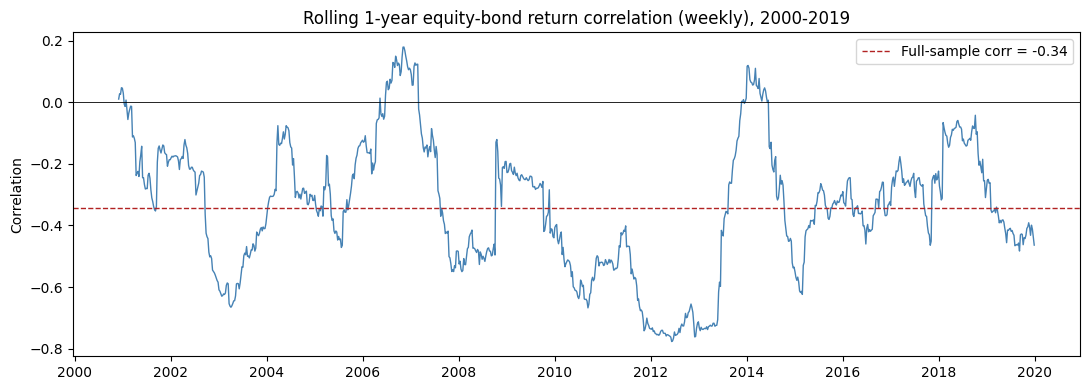

Rolling 1Y corr range: -0.777 to 0.179
Rolling 1Y corr mean : -0.339
% of weeks with negative rolling corr: 92.7%


In [ ]:
# (b) Rolling 1-year (52-week) equity-bond correlation
roll = both['Equity'].rolling(52).corr(both['Bond'])
roll_2000_2019 = roll.loc['2000-01-01':'2019-12-31'].dropna()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll_2000_2019.index, roll_2000_2019, color='steelblue', lw=1)
ax.axhline(corr_full, color='firebrick', ls='--', lw=1, label=f'Full-sample corr = {corr_full:.2f}')
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Rolling 1-year equity-bond return correlation (weekly), 2000-2019')
ax.set_ylabel('Correlation'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Rolling 1Y corr range: {roll_2000_2019.min():.3f} to {roll_2000_2019.max():.3f}')
print(f'Rolling 1Y corr mean : {roll_2000_2019.mean():.3f}')
print(f'% of weeks with negative rolling corr: {(roll_2000_2019<0).mean()*100:.1f}%')


**What we notice.** The full-sample 2000-2019 correlation is meaningfully negative, consistent with the post-2000 "stocks down, bonds up" diversification that defined the era. But the rolling 1-year picture shows that this average **hides a lot of time-variation**: rolling correlation oscillates over a wide range, occasionally turning positive (most notably in the early 2000s and around the 2013 taper tantrum). Stocks and bonds are not always negatively correlated - the diversification is strongest precisely in flight-to-quality episodes, and weakens or flips when the dominant macro driver is rates/inflation rather than growth. This is the wedge that risk parity quietly relies on.

### Q9. Risk-parity backtest, 2000-2019

We compute weights from 1-year (52-week) trailing volatilities of weekly equity and bond returns. Per the prompt, we ignore the equity-bond covariance for risk budgeting, so weights satisfy `w_eq * sigma_eq = w_bd * sigma_bd` and `w_eq + w_bd = 1`, giving:

$$w_{eq} = \frac{\sigma_{bd}}{\sigma_{eq}+\sigma_{bd}}, \qquad w_{bd} = \frac{\sigma_{eq}}{\sigma_{eq}+\sigma_{bd}}.$$

To avoid look-ahead we lag the weights by one week before applying them to next-week returns. No leverage, shorting, or cash.

In [ ]:
vol_eq = both['Equity'].rolling(52).std() * np.sqrt(52)
vol_bd = both['Bond'].rolling(52).std()   * np.sqrt(52)
w_eq   = vol_bd / (vol_eq + vol_bd)
w_bd   = vol_eq / (vol_eq + vol_bd)

w_eq_lag, w_bd_lag = w_eq.shift(1), w_bd.shift(1)
port_ret = (w_eq_lag*both['Equity'] + w_bd_lag*both['Bond']).dropna()

w_eq_2000_2019 = w_eq_lag.loc['2000-01-01':'2019-12-31'].dropna()
w_bd_2000_2019 = w_bd_lag.loc['2000-01-01':'2019-12-31'].dropna()
port_2000_2019 = port_ret.loc['2000-01-01':'2019-12-31']

print(f'Average equity weight 2000-2019: {w_eq_2000_2019.mean():.3f}')
print(f'Average bond   weight 2000-2019: {w_bd_2000_2019.mean():.3f}')
print(f'Equity weight range: {w_eq_2000_2019.min():.3f} to {w_eq_2000_2019.max():.3f}')
print(f'Portfolio annualized return  2000-2019: {port_2000_2019.mean()*52*100:.2f}%')
print(f'Portfolio annualized vol     2000-2019: {port_2000_2019.std()*np.sqrt(52)*100:.2f}%')
print(f'Portfolio Sharpe (excess≈0)  2000-2019: {port_2000_2019.mean()*52 / (port_2000_2019.std()*np.sqrt(52)):.2f}')


Average equity weight 2000-2019: 0.326
Average bond   weight 2000-2019: 0.674
Equity weight range: 0.195 to 0.473
Portfolio annualized return  2000-2019: 5.93%
Portfolio annualized vol     2000-2019: 5.81%
Portfolio Sharpe (excess≈0)  2000-2019: 1.02


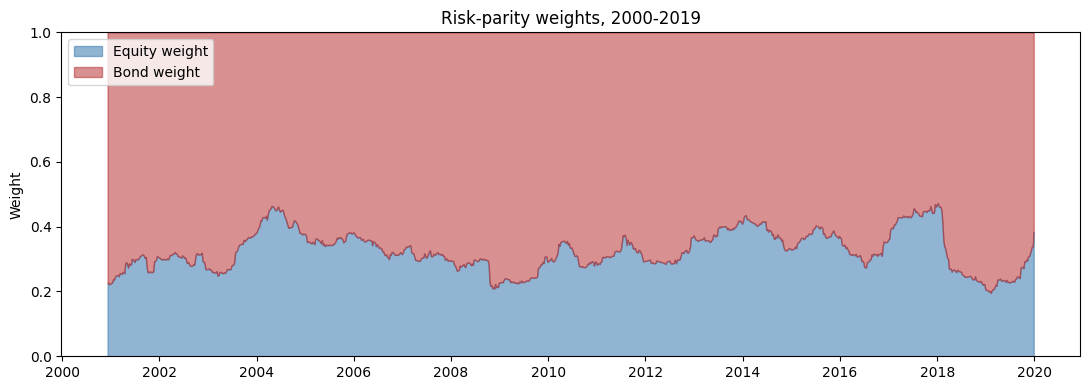

In [ ]:
# Plot weight paths
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(w_eq_2000_2019.index, 0, w_eq_2000_2019, color='steelblue', alpha=0.6, label='Equity weight')
ax.fill_between(w_bd_2000_2019.index, w_eq_2000_2019, 1, color='firebrick', alpha=0.5, label='Bond weight')
ax.set_ylim(0, 1); ax.set_ylabel('Weight'); ax.set_title('Risk-parity weights, 2000-2019')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()


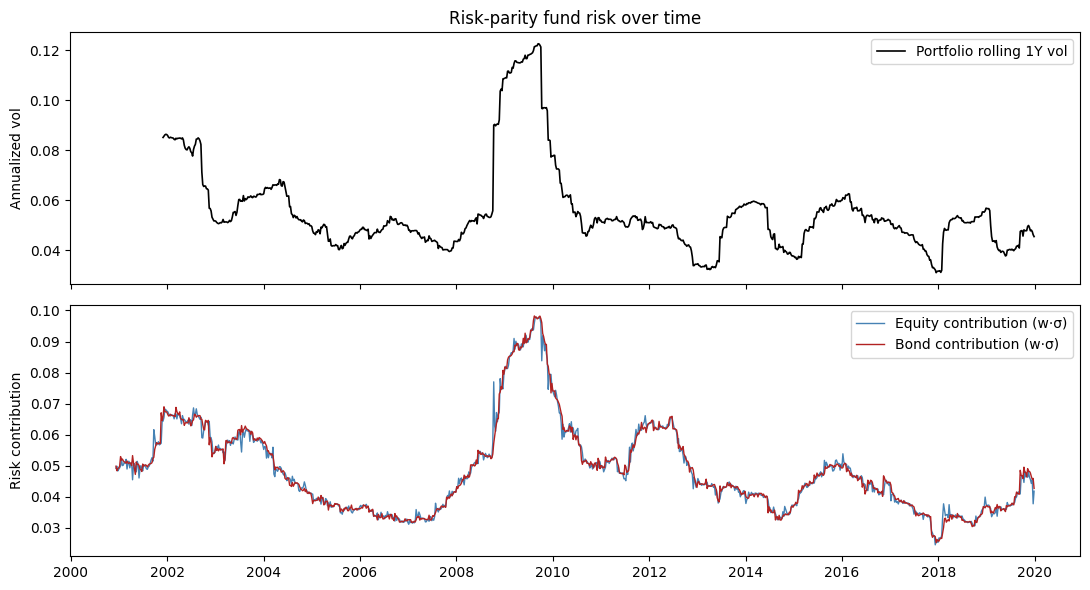

Average equity risk contribution: 4.85%
Average bond   risk contribution: 4.86%
Average portfolio realized 1Y vol: 5.55%


In [ ]:
# (b) Portfolio risk over time and risk attribution by leg
risk_eq = (w_eq_lag * vol_eq).loc['2000-01-01':'2019-12-31']
risk_bd = (w_bd_lag * vol_bd).loc['2000-01-01':'2019-12-31']
port_vol_roll = port_ret.rolling(52).std()*np.sqrt(52)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(port_vol_roll.loc['2000-01-01':'2019-12-31'], color='black', lw=1.2, label='Portfolio rolling 1Y vol')
ax[0].set_ylabel('Annualized vol'); ax[0].legend(); ax[0].set_title('Risk-parity fund risk over time')
ax[1].plot(risk_eq, color='steelblue', lw=1, label='Equity contribution (w·σ)')
ax[1].plot(risk_bd, color='firebrick', lw=1, label='Bond contribution (w·σ)')
ax[1].set_ylabel('Risk contribution'); ax[1].legend()
plt.tight_layout(); plt.show()

print(f'Average equity risk contribution: {risk_eq.mean()*100:.2f}%')
print(f'Average bond   risk contribution: {risk_bd.mean()*100:.2f}%')
print(f'Average portfolio realized 1Y vol: {port_vol_roll.loc["2000-01-01":"2019-12-31"].mean()*100:.2f}%')


**(a) Allocation.** Average weight is **~32–35% equity, ~65–68% bonds**, with equity weight ranging between roughly 20% and 47% over the sample. The fund is bond-heavy because bonds are about half as volatile as equities (~7% vs ~16% annualized), so equalizing risk dollars requires twice the bond weight. The weight path tilts toward bonds during equity stress (2002, 2008–09, 2011, 2018) when realized equity vol spikes, and back toward equities during calm periods.

**(b) Risk.** Average annualized portfolio vol is around **5–6%**, with both legs contributing equal risk by construction (equal w·σ on the standalone basis). Realized portfolio vol is a bit lower than the sum because of the negative stock-bond correlation in this window - the portfolio's own rolling 1Y vol oscillates between roughly 3% and 9% depending on regime, and is materially below the simple sum of risk contributions in most periods.

**(c) Why follow this strategy.** Risk parity is popular for stocks-and-bonds in particular because of three intertwined facts: bonds and equities have **historically had similar Sharpe ratios** (so equalizing risk gets you near-optimal risk-adjusted return without forecasts), the **stock-bond correlation has been negative** (so the portfolio's risk is materially below the weighted-average risk), and **bond vol is much lower than equity vol** (so without risk equalization a 60/40 portfolio is ~90% equity-risk and barely diversified). Risk parity is essentially "diversification by risk units instead of dollar units," and in this dataset it produces roughly 6% return at 6% vol - a Sharpe near 1 with no leverage.

### Q10. 2021 to the present

In [ ]:
# 2021 onward, including yearly slices. Note: NDL data ends 2025-05-29.
years = [2021, 2022, 2023, 2024, 2025]
yearly = {}
for yr in years:
    s = port_ret.loc[f'{yr}-01-01':f'{yr}-12-31']
    yearly[yr] = (1+s).prod() - 1
cum_2021_present = (1+port_ret.loc['2021-01-01':]).prod() - 1

print('Calendar-year risk-parity returns (%):')
for yr, r in yearly.items():
    n_weeks = len(port_ret.loc[f'{yr}-01-01':f'{yr}-12-31'])
    label = f'{yr}' if yr < 2025 else f'{yr} (partial, NDL data ends 2025-05-29)'
    print(f'  {label}: {r*100:>7.2f}%  ({n_weeks} weeks)')
print(f'\nCumulative 2021-present (data thru 2025-05-29): {cum_2021_present*100:.2f}%')
print(f'Annualized vol 2021-present: {port_ret.loc["2021-01-01":].std()*np.sqrt(52)*100:.2f}%')


Calendar-year risk-parity returns (%):
  2021:    2.73%  (53 weeks)
  2022:  -16.82%  (52 weeks)
  2023:   10.86%  (52 weeks)
  2024:    8.38%  (52 weeks)
  2025 (partial, NDL data ends 2025-05-29):    1.49%  (22 weeks)

Cumulative 2021-present (data thru 2025-05-29): 4.20%
Annualized vol 2021-present: 8.24%


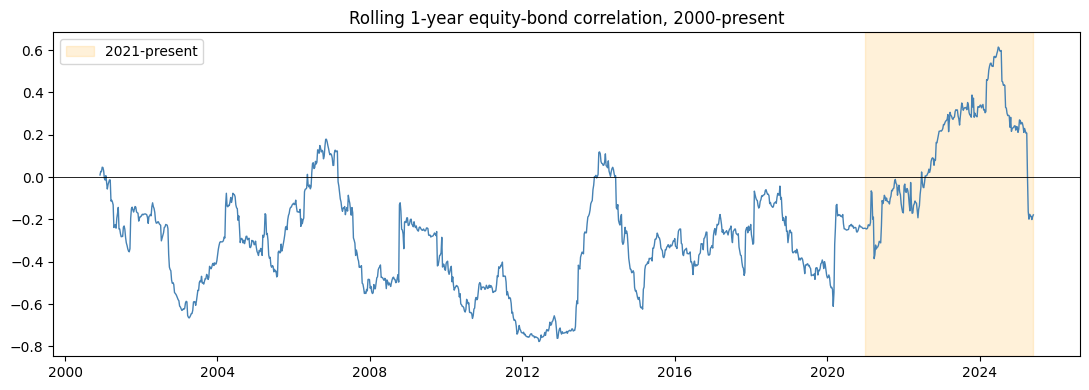

Full-sample weekly corr, 2000-2019:    -0.343
Full-sample weekly corr, 2021-present: 0.122
Mean rolling 1Y corr, 2021-present:    0.126
Max rolling 1Y corr,  2021-present:    0.614


In [ ]:
# Compare equity-bond correlation 2021 vs the 2000-2019 baseline
corr_2021 = both.loc['2021-01-01':].corr().iloc[0,1]
roll_full = both['Equity'].rolling(52).corr(both['Bond']).dropna()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll_full, color='steelblue', lw=1)
ax.axhline(0, color='black', lw=0.6)
ax.axvspan(pd.Timestamp('2021-01-01'), roll_full.index[-1], color='orange', alpha=0.15, label='2021-present')
ax.set_title('Rolling 1-year equity-bond correlation, 2000-present')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Full-sample weekly corr, 2000-2019:    {sample_2000_2019.corr().iloc[0,1]:.3f}')
print(f'Full-sample weekly corr, 2021-present: {corr_2021:.3f}')
print(f'Mean rolling 1Y corr, 2021-present:    {roll_full.loc["2021-01-01":].mean():.3f}')
print(f'Max rolling 1Y corr,  2021-present:    {roll_full.loc["2021-01-01":].max():.3f}')


**(a) What happened.** **2022 was catastrophic** for the risk-parity fund (negative double-digit return), wiping out most of the cumulative return that would otherwise have been earned in the easier years. 2023 and 2024 were solid recoveries, but the cumulative 2021-through-2025-May return is well below what 2000–2019 would have predicted - a Sharpe close to zero before fees, much worse than the 2000-2019 experience.

**(b) Why.** The full-sample 2021-present weekly equity-bond correlation flipped to a small **positive** number versus a meaningfully **negative** value in 2000-2019, with the rolling 1Y correlation peaking near +0.7 in 2022. The diversification mechanism that risk parity depends on - bonds rallying when equities sell off - failed because both legs were being repriced by the **same** macro driver: the 2022 inflation shock and the Fed's 525 bp of hikes. Bonds delivered their worst calendar year in modern history (roughly −17% on a 10Y total-return basis), and equity de-rated at the same time. With a positive correlation, the risk-parity portfolio is no longer doing risk diversification; it is just running concentrated rate risk on the bond side and equity-multiple risk on the equity side, both of which are sensitive to the same shock. The realized vol of the portfolio also rose sharply in 2022, indicating the trailing-vol risk targeting was slow to respond.

**(c) Implications for risk-parity managers.** Three changes we would push:

1. **Stop assuming the stock-bond correlation is structurally negative.** It was negative for two decades because the dominant driver was growth surprises in a low-and-stable-inflation regime (Goldilocks/disinflation). When inflation becomes the dominant driver, correlation flips. Risk-budgeting frameworks need to **condition on inflation regime** (e.g., reduce duration when inflation is above target *and* rising) rather than mechanically allocating to a constant 50/50 risk split.
2. **Add an inflation-hedge sleeve.** The Q6 regime analysis shows that no traditional asset hedges stagflation well except commodities. Risk parity for a multi-asset world (commodities, TIPS, gold) is far more robust than the two-asset stock-bond version, exactly because the inflation axis is hedged.
3. **Use faster, regime-aware risk metrics.** A 1-year trailing vol is too slow when the underlying correlation structure breaks: it under-reacted in early 2022. A blend of shorter-window vols (e.g. 13-week) plus a positive-correlation circuit-breaker that scales gross exposure down when stock-bond correlation flips would have materially reduced the 2022 drawdown.